## Scraping HW 10
***Scrape the following sites using Playwright and the magical scraping prompt Links to an external site.***

### 1. All the wells in North Dakota 

**https://www.dmr.nd.gov/oilgas/findwellsvw.asp**

- *You'll probably need to wait for the table to show up. You can wait for specific bits of text or use time.sleep(2)*

- *I recommend looping through the Townships*

In [8]:
from tqdm.notebook import tqdm

all_townships = [str(i) for i in range(129, 165)]  # 129–164
all_dataframes = []

async def scrape_all_townships_tqdm():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()
        await page.goto("https://www.dmr.nd.gov/oilgas/findwellsvw.asp", wait_until="networkidle")
        
        # tqdm progress bar
        for township in tqdm(all_townships, desc="Scraping Townships"):
            print(f"Scraping Township {township}...")
            await page.select_option("#ddmTownship", township)
            await page.click("input[type='submit']")
            await page.wait_for_selector("table[summary='Well Log search results table']")
            
            html = await page.content()
            soup = BeautifulSoup(html, "html.parser")
            table = soup.find("table", summary="Well Log search results table")
            
            headers = [th.get_text(strip=True) for th in table.find("thead").find_all("th")]
            rows = []
            for tr in table.find("tbody").find_all("tr"):
                cells = [td.get_text(strip=True) for td in tr.find_all("td")]
                if cells:
                    rows.append(dict(zip(headers, cells)))
            
            df_township = pd.DataFrame(rows)
            all_dataframes.append(df_township)
            
            # Go back to main page for next Township
            await page.goto("https://www.dmr.nd.gov/oilgas/findwellsvw.asp", wait_until="networkidle")
        
        # Combine all DataFrames
        all_data = pd.concat(all_dataframes, ignore_index=True)
        return all_data

# Run async function in Jupyter
all_wells_df = await scrape_all_townships_tqdm()
all_wells_df.head()  # preview first few rows


Scraping Townships:   0%|          | 0/36 [00:00<?, ?it/s]

Scraping Township 129...
Scraping Township 130...
Scraping Township 131...
Scraping Township 132...
Scraping Township 133...


/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/bs4/__init__.py:870: RuntimeWarning: coroutine 'scrape_one_township' was never awaited
  def object_was_parsed(


Scraping Township 134...
Scraping Township 135...
Scraping Township 136...
Scraping Township 137...
Scraping Township 138...
Scraping Township 139...
Scraping Township 140...
Scraping Township 141...
Scraping Township 142...
Scraping Township 143...
Scraping Township 144...
Scraping Township 145...
Scraping Township 146...
Scraping Township 147...
Scraping Township 148...
Scraping Township 149...
Scraping Township 150...
Scraping Township 151...
Scraping Township 152...
Scraping Township 153...
Scraping Township 154...
Scraping Township 155...
Scraping Township 156...
Scraping Township 157...
Scraping Township 158...
Scraping Township 159...
Scraping Township 160...
Scraping Township 161...
Scraping Township 162...
Scraping Township 163...
Scraping Township 164...


,File No,CTB No,API No,Well Type,Well Status,Status Date,DTD,Location,Operator,Well Name,Field
0,3065,,3308100001,OG,DRY,1/1/1962,1214,NWNW 9-129-58,SARGENT MINERAL CORP.,LAMPORT 1,WILDCAT
1,99025,,3302199025,ST,DRY,9/30/1963,1600,NENE 10-129-63,JACK ROUSE OIL PROPERTIES,HAROLD BILLIE 1,WILDCAT
2,515,,3302100001,OG,DRY,11/17/1954,1882,SENW 11-129-63,H. HANSON OIL SYNDICATE,HAROLD BILLEY 1,WILDCAT
3,572,,3302100002,OG,DRY,6/17/1954,1860,NENW 14-129-63,H. HANSON OIL SYNDICATE,JOHN BELL 1,WILDCAT
4,1394,,3302100005,OG,DRY,3/12/1957,3166,NWNW 22-129-66,"CALVERT DRILLING, INC.",MARVIN KAMM 1,WILDCAT


In [9]:
# Save the full results to CSV
output_file = "nd_oil_gas_wells.csv"
all_wells_df.to_csv(output_file, index=False)

print(f"✅ All data saved to {output_file}")

✅ All data saved to nd_oil_gas_wells.csv


### 2. Cosmetology violations for licensees with the last name NGUYEN

**https://www.tdlr.texas.gov/cimsfo/fosearch.asp**
- *It's a table of data, but it's kind of tricky - you need to make sure that the City, License #, Name, etc are all in different columns*

In [17]:
# # Install Playwright and browsers
# !pip install playwright beautifulsoup4 tqdm

# # Install browsers (only needs to be done once)
# !playwright install firefox

# Imports
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
import pandas as pd
from tqdm.notebook import tqdm
import asyncio


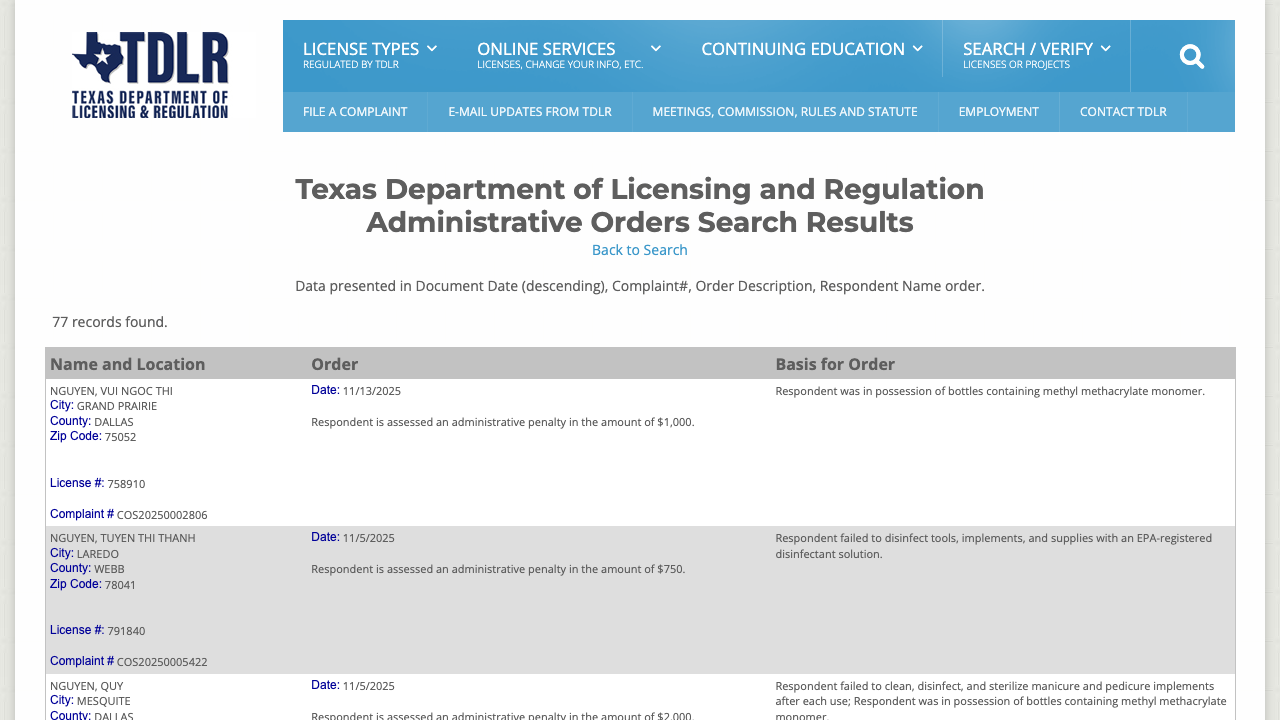

In [19]:
async def fetch_results():
    async with async_playwright() as p:
        # Launch headed Firefox
        browser = await p.firefox.launch(headless=False)
        context = await browser.new_context()
        page = await context.new_page()
        
        # Go to the page
        await page.goto("https://www.tdlr.texas.gov/cimsfo/", wait_until="networkidle")
        
        # Select "Cosmetologists" from License Program Type dropdown by value
        await page.select_option('#pht_status', value="COS")
        
        # Enter "Nguyen" in Last Name text box
        await page.fill('#pht_lnm', "Nguyen")
        
        # Click the Search button
        await page.click('input[name="B1"]')
        
        # Wait for results to load (network idle)
        await page.wait_for_load_state("networkidle")
        
        # Take a screenshot for visual confirmation
        screenshot = await page.screenshot()
        
        # Get page content
        content = await page.content()
        
        await browser.close()
        return content, screenshot

# Run the async function
content, screenshot = asyncio.run(fetch_results())

# Display the screenshot in notebook
from IPython.display import Image
Image(screenshot)

In [23]:
# Parse the page content with BeautifulSoup
soup = BeautifulSoup(content, "html.parser")

# Find all result rows
rows = soup.find_all("tr", style="background:#ffffff;")

data = []

for row in rows:
    tds = row.find_all("td")
    if len(tds) < 3:
        continue  # skip rows that aren't result rows

    # First td contains name, city, county, zip, license #, complaint #
    td1 = tds[0]
    name = td1.find("span", class_="results_text").get_text(strip=True)
    
    # Updated get_field function to correctly handle License # and other fields
    def get_field(label):
        for span in td1.find_all("span", class_="default_text"):
            if span.get_text(strip=True) == label:
                next_span = span.find_next("span", class_="results_text")
                if next_span:
                    return next_span.get_text(strip=True)
        return ""
    
    city = get_field("City:")
    county = get_field("County:")
    zip_code = get_field("Zip Code:")
    license_num = get_field("License #:")
    complaint_num = get_field("Complaint #")
    
    # Second td contains date and penalty/action
    td2 = tds[1]
    date_span = td2.find("span", class_="results_text")
    date = date_span.get_text(strip=True) if date_span else ""
    penalty = td2.get_text(separator=" ", strip=True).replace(date, "").strip()
    
    # Third td contains violation/reason
    td3 = tds[2]
    violation = td3.get_text(strip=True)
    
    data.append({
        "Name": name,
        "City": city,
        "County": county,
        "Zip Code": zip_code,
        "License #": license_num,
        "Complaint #": complaint_num,
        "Date": date,
        "Penalty/Action": penalty,
        "Violation/Reason": violation
    })

# Convert to DataFrame
df = pd.DataFrame(data)

# Preview the results
df.head()


,Name,City,County,Zip Code,License #,Complaint #,Date,Penalty/Action,Violation/Reason
0,"NGUYEN, VUI NGOC THI",GRAND PRAIRIE,DALLAS,75052,758910,COS20250002806,11/13/2025,Date: Respondent is assessed an administrativ...,Respondent was in possession of bottles contai...
1,"NGUYEN, QUY",MESQUITE,DALLAS,75149,722334,COS20250005583,11/5/2025,Date: Respondent is assessed an administrativ...,"Respondent failed to clean, disinfect, and ste..."
2,"NGUYEN, KEVIN C",KYLE,HAYS,78640,834106,COS20250010661,10/6/2025,Date: Respondent is assessed an administrativ...,Respondent employed an individual as an operat...
3,"NGUYEN, QUANG XUAN",GARLAND,DALLAS,75042,738063,COS20250004028,9/25/2025,Date: Respondent is assessed an administrativ...,Respondent was in possession of bottles contai...
4,"NGUYEN, KIET TUAN",SAN ANTONIO,BEXAR,78253,1294327,COS20250013094,9/2/2025,Date: Respondent's Manicurist license was rev...,Respondent's license was revoked upon Responde...


In [24]:
# Save DataFrame to CSV
df.to_csv("tdlr_cosmetologists_nguyen.csv", index=False)
print("CSV saved as tdlr_cosmetologists_nguyen.csv")


CSV saved as tdlr_cosmetologists_nguyen.csv


### 3. All the tow truck licenses in Houston

**https://www.tdlr.texas.gov/tools_search/**
- *It won't let you search for just Houston, so you probably need a list of zip codes. Should you just ask ChatGPT? Or should you not??*
- *It might probably try to use BeautifulSoup. Don't let it!*
- *Honestly you can just use a few zip codes, like 5 or 10.*
- *Is there pagination on the results page if you have a lot of them?? Is there any way to find out??*

In [41]:
# Cell 1: Import libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Base URL for the TDLR search results
base_url = "https://www.tdlr.texas.gov/tools_search/mccs_search_process.asp"

# Parameters for the search
params = {
    "stype": "city",
    "ls_temp": "HOUSTON",
    "ls_carrier_type": "tow",
    "ls_cert_status": "ALL",
    "page": 1  # start with page 1
}

# Fetch the first page
response = requests.get(base_url, params=params)
response.raise_for_status()  # make sure the request worked

# Parse the HTML
soup = BeautifulSoup(response.text, "html.parser")

# Preview the first 1000 characters to confirm we have the right page
print(response.text[:1000])




<html>
<head>
	<title>TDLR Tow Truck and Vehicle Storage Facility Inquiry</title>

<meta	content="text/html; charset=windows-1252" http-equiv="Content-Type" />
<meta	NAME="GENERATOR" Content="Microsoft Visual Studio" /> 

<meta	HTTP-EQUIV="Content-Type" content="text/html; charset=UTF-8" />
<meta	name="description" 
		content="Welcome to the Tow Truck and Vehicle Storage Facility Inquiry Information Page. 
				This web application allows users to obtain information on companies that have 
				obtained registration through TDLR. This includes addresses, insurance records, 
				recent activities, and vehicle data." />
<meta	name="keywords" 
		content="Tow Trucks, Vehicle Storage Facility, registration, insurance, Permit 
				Restrictions, Texas Department of Licensing and Regulation, TDLR" />
<meta	name="subject" content="Transportation" />
<meta	name="type" content="Programs and services" />
<meta	name="author" content="Texas Department of Licensing and Regulation 


In [42]:
# Cell 2: Parse the table rows
data = []

# The rows are inside <tr> tags; skip header rows by checking number of <td> elements
for row in soup.find_all("tr"):
    cols = row.find_all("td")
    if len(cols) == 6:
        customer = cols[0].get_text(strip=True)
        dba_name = cols[1].get_text(strip=True)
        
        # Split TDLR Number and Status
        tdlr_text = cols[2].get_text(strip=True)
        if "(" in tdlr_text:
            tdlr_number = tdlr_text.split("(")[0].strip()
            status = tdlr_text.split("(")[1].replace(")", "").strip()
        else:
            tdlr_number = tdlr_text
            status = ""
        
        city = cols[3].get_text(strip=True)
        state = cols[4].get_text(strip=True)
        zip_code = cols[5].get_text(strip=True)
        
        data.append([customer, dba_name, tdlr_number, status, city, state, zip_code])

# Create a DataFrame
df = pd.DataFrame(data, columns=["Customer", "DBA Name", "TDLR Number", "Status", "City", "State", "Zip code"])

# Preview the first few rows
df.head()


,Customer,DBA Name,TDLR Number,Status,City,State,Zip code


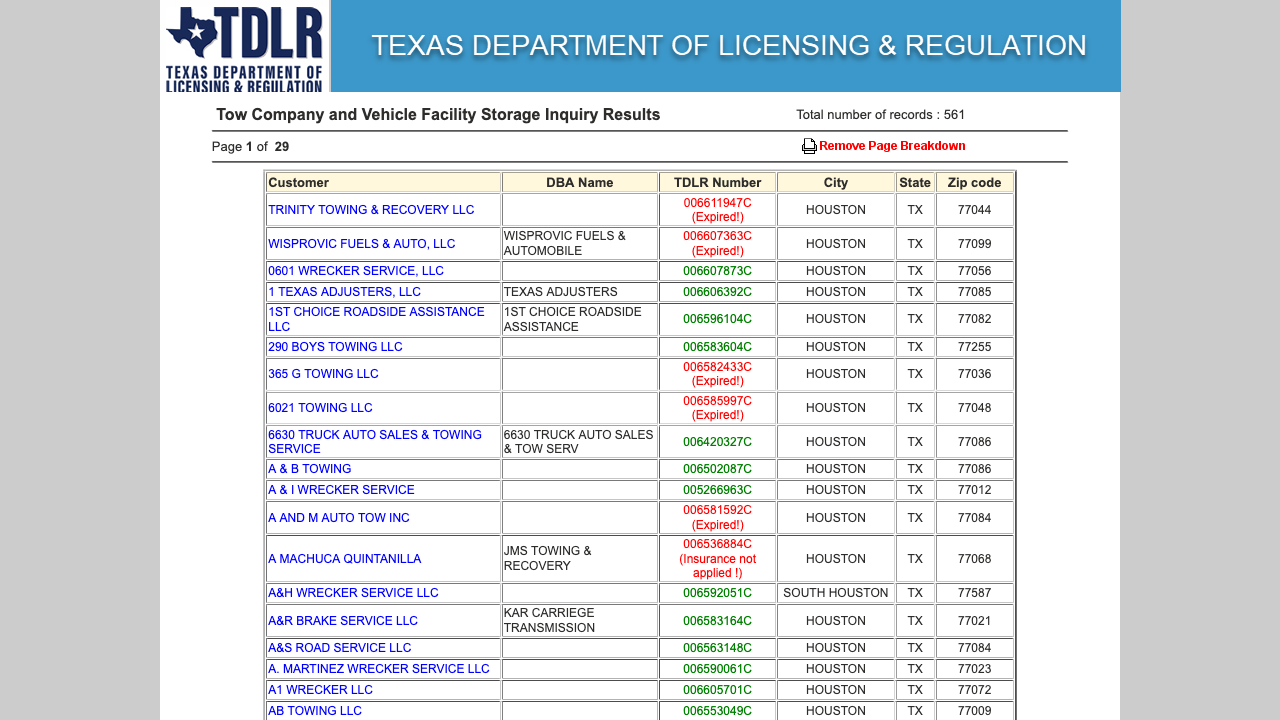

Page fetched and ready for parsing!


In [43]:
# Cell 6 (updated): Playwright setup for headful mode
from playwright.async_api import async_playwright
import asyncio
from bs4 import BeautifulSoup

async def fetch_page():
    async with async_playwright() as p:
        # Launch Firefox in headful mode
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()
        
        # Go to the search page
        await page.goto("https://www.tdlr.texas.gov/tools_search/", wait_until="networkidle")
        
        # Click the "City" radio button
        await page.click("#citybutton")
        
        # Fill in "HOUSTON" in the city input
        await page.fill("#citydata", "HOUSTON")
        
        # Select "Show All" in city status
        await page.select_option("#city_status", "ALL")
        
        # Select "Tow Truck" in carrier type
        await page.select_option("#city_carrier_type", "tow")
        
        # Submit the form by clicking the correct button
        await page.click("#submit3")
        
        # Wait for results to load
        await page.wait_for_load_state("networkidle")
        
        # Take a screenshot to confirm (optional)
        screenshot = await page.screenshot()
        from IPython.display import display, Image
        display(Image(screenshot))
        
        # Get the page content and return
        content = await page.content()
        
        await browser.close()
        return content

# Run the async function and get the HTML
page_html = asyncio.run(fetch_page())

# Parse with BeautifulSoup
soup = BeautifulSoup(page_html, "html.parser")
print("Page fetched and ready for parsing!")


In [44]:
# Cell 11: Scrape all pages using the "Next" button
all_data = []

async def fetch_all_pages_next():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()
        
        # Submit form once
        await page.goto("https://www.tdlr.texas.gov/tools_search/", wait_until="networkidle")
        await page.click("#citybutton")
        await page.fill("#citydata", "HOUSTON")
        await page.select_option("#city_status", "ALL")
        await page.select_option("#city_carrier_type", "tow")
        await page.click("#submit3")
        await page.wait_for_load_state("networkidle")
        
        page_num = 1
        while True:
            print(f"Scraping page {page_num}...")
            
            # Parse current page
            content = await page.content()
            soup = BeautifulSoup(content, "html.parser")
            
            # Find the results table
            tables = soup.find_all("table")
            results_table = None
            for table in tables:
                for row in table.find_all("tr"):
                    if len(row.find_all("td")) == 6:
                        results_table = table
                        break
                if results_table:
                    break
            
            if results_table is None:
                print(f"No results table found on page {page_num}")
                break
            
            # Parse rows, skipping header
            rows = results_table.find_all("tr")[1:]
            for row in rows:
                cols = row.find_all("td")
                if len(cols) == 6:
                    customer = cols[0].get_text(strip=True)
                    dba_name = cols[1].get_text(strip=True)
                    
                    tdlr_text = cols[2].get_text(strip=True)
                    if "(" in tdlr_text:
                        tdlr_number = tdlr_text.split("(")[0].strip()
                        status = tdlr_text.split("(")[1].replace(")", "").strip()
                    else:
                        tdlr_number = tdlr_text
                        status = ""
                    
                    city = cols[3].get_text(strip=True)
                    state = cols[4].get_text(strip=True)
                    zip_code = cols[5].get_text(strip=True)
                    
                    all_data.append([customer, dba_name, tdlr_number, status, city, state, zip_code])
            
            # Check if a "Next" button exists
            next_buttons = page.locator("a", has_text="Next")
            if await next_buttons.count() == 0:
                print("No more pages. Scraping complete.")
                break
            
            # Click the "Next" button and wait for page to load
            await next_buttons.first.click()
            await page.wait_for_load_state("networkidle")
            page_num += 1
            await asyncio.sleep(1)  # small delay for stability
        
        await browser.close()

# Run the async function
asyncio.run(fetch_all_pages_next())

# Create DataFrame and save as CSV
df_all = pd.DataFrame(all_data, columns=["Customer", "DBA Name", "TDLR Number", "Status", "City", "State", "Zip code"])
df_all.to_csv("houston_tow_truck_licenses.csv", index=False)
print("All pages scraped and CSV saved!")
df_all.head()


Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
No more pages. Scraping complete.
All pages scraped and CSV saved!


,Customer,DBA Name,TDLR Number,Status,City,State,Zip code
0,TRINITY TOWING & RECOVERY LLC,,006611947C,Expired!,HOUSTON,TX,77044
1,"WISPROVIC FUELS & AUTO, LLC",WISPROVIC FUELS & AUTOMOBILE,006607363C,Expired!,HOUSTON,TX,77099
2,"0601 WRECKER SERVICE, LLC",,006607873C,,HOUSTON,TX,77056
3,"1 TEXAS ADJUSTERS, LLC",TEXAS ADJUSTERS,006606392C,,HOUSTON,TX,77085
4,1ST CHOICE ROADSIDE ASSISTANCE LLC,1ST CHOICE ROADSIDE ASSISTANCE,006596104C,,HOUSTON,TX,77082


### 4. Company information+violations for the following license numbers: trucks-subset.csv

- *Similar to but slightly different from the last one – in that you're basing it on a CSV of data instead of a list*
- *It might probably try to use BeautifulSoup. Don't let it!*

In [99]:
import asyncio
import pandas as pd
from playwright.async_api import async_playwright
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup

# Read your CSV
df_trucks = pd.read_csv("trucks-subset.csv")
tdlr_numbers = df_trucks["TDLR Number"].astype(str).tolist()  # adjust column name if needed


In [100]:
def parse_certificate_info_lines_fixed(td):
    carrier_type = capacity = mailing_address = physical_address = ""
    
    text = td.get_text(separator="\n").strip()
    lines = [line.strip() for line in text.split("\n") if line.strip()]
    
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("Carrier Type:"):
            parts = line.split("Carrier Type:", 1)
            if parts[1].strip():
                carrier_type = line
            elif i + 1 < len(lines):
                carrier_type = f"Carrier Type: {lines[i+1].strip()}"
                i += 1
        elif line.startswith("Capacity:"):
            parts = line.split("Capacity:", 1)
            if parts[1].strip():
                capacity = line
            elif i + 1 < len(lines):
                capacity = f"Capacity: {lines[i+1].strip()}"
                i += 1
        elif line.startswith("Mailing:"):
            addr_lines = []
            i += 1
            while i < len(lines) and not lines[i].startswith("Physical:"):
                addr_lines.append(lines[i])
                i += 1
            mailing_address = ", ".join(addr_lines)
            continue
        elif line.startswith("Physical:"):
            addr_lines = []
            i += 1
            while i < len(lines):
                addr_lines.append(lines[i])
                i += 1
            physical_address = ", ".join(addr_lines)
            break
        i += 1

    return carrier_type, capacity, mailing_address, physical_address


In [106]:
def parse_results_multiowners_searchstatus(soup, tdlr_number):
    rows = []

    # --- Company Information ---
    company_info_font = soup.find("font", string="Company Information:")
    
    row_dict = {
        "TDLR Number": tdlr_number,
        "Company Name": "",
        "DBA": "",
        "Phone": "",
        "Certificate Number": "",
        "Status": "",  # keep the original certificate status
        "Carrier Type": "",
        "Capacity": "",
        "Mailing Address": "",
        "Physical Address": "",
        "Search Status": "Not Found"  # new column for search result
    }

    if company_info_font:
        row_dict["Search Status"] = "Found"  # mark as found
        company_table = company_info_font.find_parent("tbody")

        # Name, DBA, Phone
        for td in company_table.find_all("td"):
            text = td.get_text(strip=True)
            if text.startswith("Name:"):
                row_dict["Company Name"] = text.replace("Name:", "").strip()
            elif text.startswith("DBA:"):
                row_dict["DBA"] = text.replace("DBA:", "").strip()
            elif text.startswith("Phone:"):
                row_dict["Phone"] = text.replace("Phone:", "").strip()

        # Owners
        owners = []
        for td in company_table.find_all("td"):
            text = td.get_text(strip=True)
            if text.startswith("Owner/Officer:"):
                owners.append(text.replace("Owner/Officer:", "").strip())
        for i, owner in enumerate(owners, start=1):
            row_dict[f"Owner/Officer {i}"] = owner

        # Certificate Information
        cert_info_strong = soup.find("strong", string="Certificate Information:")
        if cert_info_strong:
            cert_table = cert_info_strong.find_parent("table")
            trs = cert_table.find_all("tr")
            if len(trs) >= 2:
                data_tr = trs[1]
                tds = data_tr.find_all("td")
                if len(tds) >= 2:
                    td1 = tds[0]
                    b_tag = td1.find("b")
                    if b_tag:
                        row_dict["Certificate Number"] = b_tag.get_text(strip=True)
                    font_tags = td1.find_all("font")
                    if font_tags:
                        row_dict["Status"] = font_tags[-1].get_text(strip=True)  # keep certificate status
                    td2 = tds[1]
                    carrier_type, capacity, mailing_address, physical_address = parse_certificate_info_lines_fixed(td2)
                    row_dict["Carrier Type"] = carrier_type
                    row_dict["Capacity"] = capacity
                    row_dict["Mailing Address"] = mailing_address
                    row_dict["Physical Address"] = physical_address

    rows.append(row_dict)
    return pd.DataFrame(rows)


In [ ]:
async def search_tdrl_number(page, tdlr_number):
    await page.goto("https://www.tdlr.texas.gov/tools_search/mccs_search.asp", wait_until="networkidle")
    await page.click("#mcrbutton")
    await page.fill("#mcrdata", tdlr_number)
    await page.click("#submit3")
    await page.wait_for_load_state("networkidle")
    html = await page.content()
    return BeautifulSoup(html, "html.parser")


In [107]:
async def scrape_all_numbers_searchstatus(tdlr_numbers):
    master_df = pd.DataFrame()
    
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        context = await browser.new_context()
        page = await context.new_page()
        
        for tdlr_number in tqdm(tdlr_numbers, desc="Scraping TDLR Numbers"):
            try:
                soup = await search_tdrl_number(page, tdlr_number)
                df = parse_results_multiowners_searchstatus(soup, tdlr_number)
                master_df = pd.concat([master_df, df], ignore_index=True)
            except Exception as e:
                print(f"Error with {tdlr_number}: {e}")
        
        await browser.close()
    return master_df


In [109]:
master_df_searchstatus = asyncio.run(scrape_all_numbers_searchstatus(tdlr_numbers))

# Save CSV
master_df_searchstatus.to_csv("tdlr_results.csv", index=False)
master_df_searchstatus.head()


Scraping TDLR Numbers:   0%|          | 0/3 [00:00<?, ?it/s]

,TDLR Number,Company Name,DBA,Phone,Certificate Number,Status,Carrier Type,Capacity,Mailing Address,Physical Address,Search Status,Owner/Officer 1,Owner/Officer 2,Owner/Officer 3
0,006565540C,,,,,,,,,,Not Found,NaN,NaN,NaN
1,0654479VSF,24/7TOWINGANDRECOVERYLLC,MIDLAND TOWING AND RECOVERY,4325576733,0654479VSF,Active,Carrier Type: Vehicle Storage Facility,Capacity: <=50,"3601 N COUNTY ROAD 1148, MIDLAND, TX. 79705","3601 N COUNTY ROAD 1148, MIDLAND, TX. 79705",Found,SCOTT JENSON ...,CHRIS BRENES ...,PEERY A HOLMSLEY ...
2,006564940C,A&NTOWINGLLC,NO DATA,2106678546,006564940C,006564940C(Expired),Carrier Type: Tow Truck Company,,"10838 DEEPWATER BAY, SAN ANTONIO, TX. 78251","1341 GAYLE LN, POTEET, TX. 78065",Found,ABDULRAHMAN Z ALABDULLAH ...,NaN,NaN
